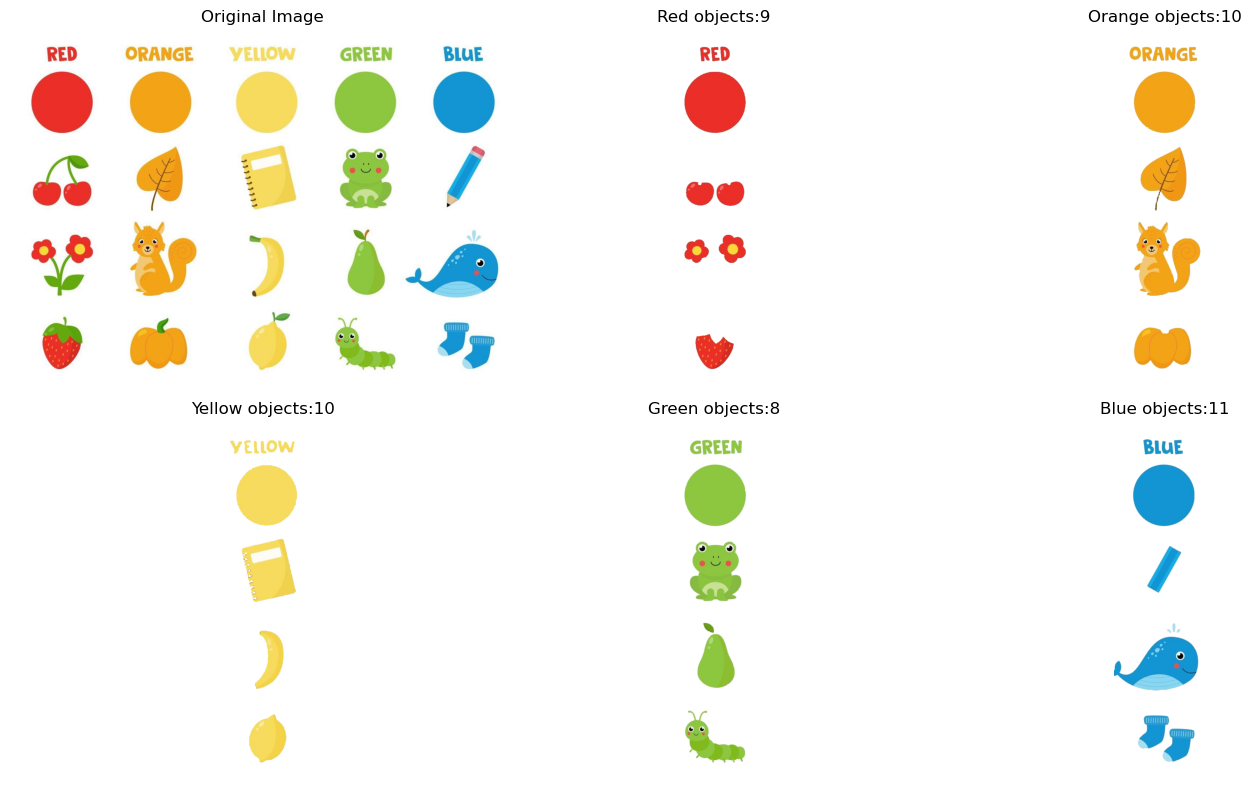

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('colores.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

ancho = imagen_rgb.shape[1]
paso = ancho // 5

col_rojo = imagen_rgb[:, 0:paso]
col_naranja = imagen_rgb[:, paso:2*paso]
col_amarillo = imagen_rgb[:, 2*paso:3*paso]
col_verde = imagen_rgb[:, 3*paso:4*paso]
col_azul = imagen_rgb[:, 4*paso:ancho]

def procesar_columna(columna_rgb, b1, a1, area_minima, b2=None, a2=None):
    columna_hsv = cv2.cvtColor(columna_rgb, cv2.COLOR_RGB2HSV)
    
    mascara = cv2.inRange(columna_hsv, b1, a1)
    if b2 is not None:
        mascara2 = cv2.inRange(columna_hsv, b2, a2)
        mascara = cv2.bitwise_or(mascara, mascara2)
        
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    cuenta = 0
    mascara_limpia = np.zeros_like(mascara)
    
    for c in contornos:
        if cv2.contourArea(c) >= area_minima:
            cuenta += 1
            cv2.drawContours(mascara_limpia, [c], -1, 255, -1)
            
    fondo_blanco = np.ones_like(columna_rgb) * 255
    objetos = cv2.bitwise_and(columna_rgb, columna_rgb, mask=mascara_limpia)
    mascara_inv = cv2.bitwise_not(mascara_limpia)
    fondo = cv2.bitwise_and(fondo_blanco, fondo_blanco, mask=mascara_inv)
    resultado = cv2.add(objetos, fondo)
    
    return resultado, cuenta

b_rojo1 = np.array([0, 100, 100])
a_rojo1 = np.array([10, 255, 255])
b_rojo2 = np.array([170, 100, 100])
a_rojo2 = np.array([180, 255, 255])
res_rojo, cant_rojo = procesar_columna(col_rojo, b_rojo1, a_rojo1, 10, b_rojo2, a_rojo2)

b_naranja = np.array([11, 100, 100])
a_naranja = np.array([25, 255, 255])
res_naranja, cant_naranja = procesar_columna(col_naranja, b_naranja, a_naranja, 10)

b_amarillo = np.array([22, 120, 120])
a_amarillo = np.array([35, 255, 255])
res_amarillo, cant_amarillo = procesar_columna(col_amarillo, b_amarillo, a_amarillo, 25)

b_verde = np.array([36, 50, 50])
a_verde = np.array([85, 255, 255])
res_verde, cant_verde = procesar_columna(col_verde, b_verde, a_verde, 15)

b_azul = np.array([86, 50, 50])
a_azul = np.array([140, 255, 255])
res_azul, cant_azul = procesar_columna(col_azul, b_azul, a_azul, 15)

plt.figure(figsize=(15, 8))

plt.subplot(231)
plt.imshow(imagen_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(232)
plt.imshow(res_rojo)
plt.title(f'Red objects:{cant_rojo}')
plt.axis('off')

plt.subplot(233)
plt.imshow(res_naranja)
plt.title(f'Orange objects:{cant_naranja}')
plt.axis('off')

plt.subplot(234)
plt.imshow(res_amarillo)
plt.title(f'Yellow objects:{cant_amarillo}')
plt.axis('off')

plt.subplot(235)
plt.imshow(res_verde)
plt.title(f'Green objects:{cant_verde}')
plt.axis('off')

plt.subplot(236)
plt.imshow(res_azul)
plt.title(f'Blue objects:{cant_azul}')
plt.axis('off')

plt.tight_layout()
plt.show()